In [9]:
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
path_data_clean = "../data_clean/"

file_data_bersih = os.path.join(path_data_clean, "dataset_final_2021-2023.csv")


df = pd.read_csv(file_data_bersih)
print("Data Loaded:", df.shape)
print(df.head())

cols_to_numeric = ['P1', 'UHH', 'HLS', 'RLS', 'Pengeluaran', 'TPT', 'Kepadatan']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')


Data Loaded: (105, 9)
                  Wilayah  Tahun    P1    UHH    HLS   RLS  Pengeluaran   TPT  \
0       Kabupaten Cilacap   2021  1.48  73.90  12.63  7.09        10534  9.97   
1      Kabupaten Banyumas   2021  2.35  73.80  13.03  7.63        11546  6.05   
2   Kabupaten Purbalingga   2021  2.10  73.21  12.00  7.25        10032  6.05   
3  Kabupaten Banjarnegara   2021  2.97  74.28  11.63  6.75         9407  5.86   
4       Kabupaten Kebumen   2021  3.24  73.55  13.35  7.55         9028  6.03   

   Kepadatan  
0        924  
1       1340  
2       1487  
3       1003  
4       1124  


SPLIT TRAIN–TEST BERDASARKAN TAHUN

Train = 2021–2022
Test = 2023

In [11]:
df_train = df[df['Tahun'] < 2023]
df_test  = df[df['Tahun'] == 2023]

X_train = df_train[cols_to_numeric[1:]]  # All X
y_train = df_train['P1']

X_test = df_test[cols_to_numeric[1:]]
y_test = df_test['P1']


FIT MODEL REGRESI (statsmodels OLS)

In [12]:
# tambah intercept
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     P1   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     8.124
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           1.62e-06
Time:                        10:54:59   Log-Likelihood:                -54.130
No. Observations:                  70   AIC:                             122.3
Df Residuals:                      63   BIC:                             138.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          13.6849      4.852      2.820      

CEK MULTIKOLINEARITAS (VIF)

Interpretasi:
- VIF > 10 → multikolinearitas parah
- VIF 5–10 → waspada
- VIF < 5 → aman


In [13]:
vif_df = pd.DataFrame()
vif_df['Variable'] = X_train.columns
vif_df['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

print(vif_df)


      Variable          VIF
0          UHH   620.245192
1          HLS  1877.487423
2          RLS   602.106523
3  Pengeluaran   143.829491
4          TPT    16.290746
5    Kepadatan     6.254313


UJI ASUMSI REGRESI

A. Normalitas Residual (Shapiro)

In [14]:
residuals = model.resid
shapiro_test = shapiro(residuals)
print("Shapiro-Wilk Test:", shapiro_test)


Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9725090242225468), pvalue=np.float64(0.1263495696002847))


B. QQ Plot

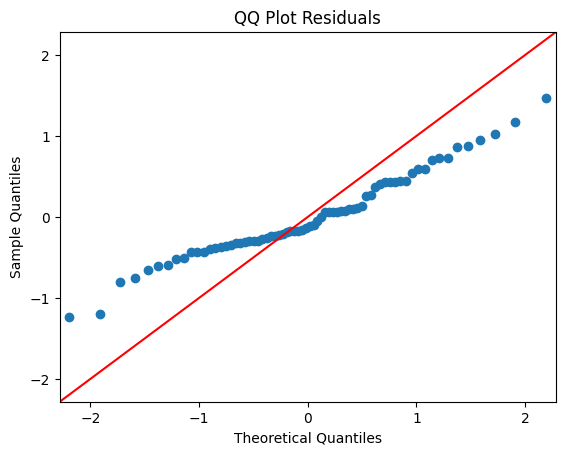

In [15]:
sm.qqplot(residuals, line='45')
plt.title("QQ Plot Residuals")
plt.show()

C. Homoskedastisitas (Breusch–Pagan)

In [16]:
bp_test = het_breuschpagan(residuals, model.model.exog)
labels = ['LM Stat', 'LM p-value', 'F-stat', 'F p-value']

print(dict(zip(labels, bp_test)))


{'LM Stat': np.float64(14.296240936750486), 'LM p-value': np.float64(0.02649648216020675), 'F-stat': np.float64(2.6948007165088317), 'F p-value': np.float64(0.021573691435828213)}


D. Plot Residual vs Fitted

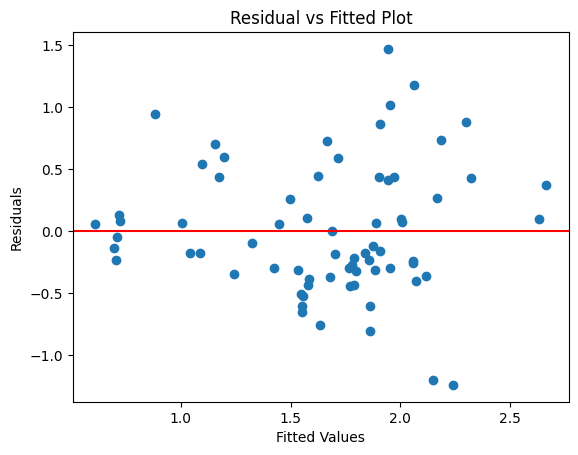

In [17]:
fitted_vals = model.fittedvalues

plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted Plot")
plt.show()


EVALUASI MODEL (Train dan Test)

Train Error

In [18]:
train_pred = model.predict(X_train_sm)

mse_train = mean_squared_error(y_train, train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, train_pred)

print("TRAIN RMSE:", rmse_train)
print("TRAIN MAE:", mae_train)


TRAIN RMSE: 0.5243214435491469
TRAIN MAE: 0.41634297437295587


Train Error

In [19]:
X_test_sm = sm.add_constant(X_test)
test_pred = model.predict(X_test_sm)

mse_test = mean_squared_error(y_test, test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, test_pred)

print("TEST RMSE:", rmse_test)
print("TEST MAE:", mae_test)


TEST RMSE: 0.5102770125773916
TEST MAE: 0.41413345446125255
